# Measure of Central Tendency 
* Mean
* Mode
* Median
* Trimmed Mean
* Weighted Mean

In [70]:
# Mean 

data = [10,20,18,14,19]

mean = sum(data)/len(data)
print(mean)

import numpy as np
mean = np.mean(data)
print(mean)

import pandas as pd 
mean = pd.Series(data).mean()
print(mean)

16.2
16.2
16.2


In [71]:
# Mode - most frequent item
from statistics import mode

Mode = mode(data)
print(mode)

<function mode at 0x0000027C686C7920>


In [72]:
# Median 
sorted_data = sorted(data)
print(sorted_data)

n = len(data)
middle = n // 2

median = sorted_data[middle]
print(median)

[10, 14, 18, 19, 20]
18


In [73]:
# Weighted Mean
import numpy as np

values = np.array([10,20,30,18,19])
weight = np.array([1,2,3,2,1])

weighted_mean = np.average(values,weights=weight)
print(weighted_mean)


21.666666666666668


In [74]:
# trimmed mean 

from scipy.stats import trim_mean

data = [10,20,18,14,19,100]
trimmed_mean = trim_mean(data,proportiontocut=0.1)
print(trimmed_mean)


30.166666666666668


# Measure of Dispersion
* Range
* Variance
* Mean Absolute Difference
* Standard Deviation
* Coefficient Variation 

In [75]:
# Range

data = [10, 20, 18, 14, 19]

data_range = max(data) - min(data)
print(data_range)

10


In [76]:
# Variance
import numpy as np 

variance = np.var(data)
print(variance)


# custom variance 
mean = sum(data) / len(data)
variance = sum((x-mean)**2 for x in data) / len(data)
print(variance)



13.76
13.76


In [77]:
# Mean Absolute Deviation
data = [10,20,18,14,19]

n = len(data)
mad = sum(abs(x - mean) for x in data) / n
print(mad)


import numpy as np
data = np.array(data)
mad = np.mean(np.abs(data - np.mean(data)))
print(mad)

3.3600000000000003
3.3600000000000003


In [78]:
# Standard Deviation
data = [10, 20, 18, 14, 19]

n = len(data)
SD = (sum((x - mean)** 2 for x in data) / n) ** .5
print(SD)

import numpy as np 
SD = np.std(data)
print(SD)

3.7094473981982814
3.7094473981982814


In [79]:
# Coefficient of Variation (CV) measures relative variability.

import numpy as np

data = [10, 20, 18, 14, 19]

mean = np.mean(data)
sd = np.std(data)

cv = (sd / mean) * 100

print(cv)

22.897823445668404


# Univariance Graph
* Categorical 
* Numerical 

In [80]:
# Categorical 
import pandas as pd
import numpy as np

# reproducibility
np.random.seed(42)

# dummy categorical data
vacation_choices = np.random.choice(
    ["Beach", "City", "Nature", "Adventure"],
    size=100,
    p=[0.30, 0.25, 0.25, 0.20]
)

# create dataframe
df = pd.DataFrame({"Vacation_Type": vacation_choices})

# frequency table
frequency_table = (df["Vacation_Type"].value_counts().reset_index())

frequency_table.columns = ["Vacation_Type", "Frequency"]

print(frequency_table)



  Vacation_Type  Frequency
0         Beach         34
1          City         25
2        Nature         23
3     Adventure         18


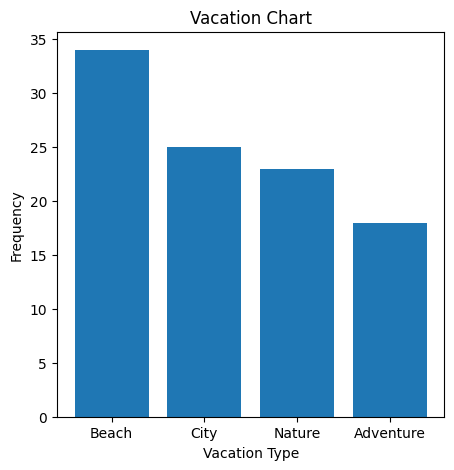

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.bar(frequency_table['Vacation_Type'],
        frequency_table['Frequency']
)

plt.title("Vacation Chart")
plt.xlabel("Vacation Type")
plt.ylabel("Frequency")
plt.show()

  Vacation_Type  Frequency  Relative Frequency
0         Beach         34                0.34
1          City         25                0.25
2        Nature         23                0.23
3     Adventure         18                0.18


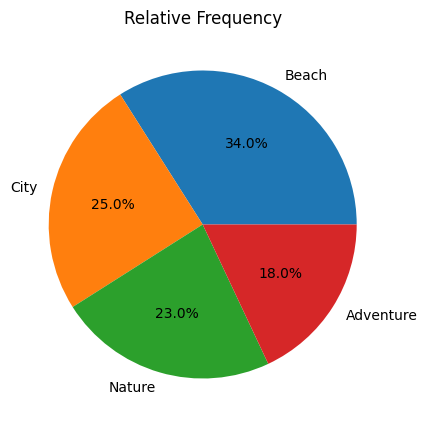

In [82]:
frequency_table['Relative Frequency'] = (
    frequency_table["Frequency"]/frequency_table["Frequency"].sum()
)

print(frequency_table)

plt.figure(figsize=(5,5))

plt.pie(
    frequency_table["Relative Frequency"],
    labels=frequency_table["Vacation_Type"],
    autopct="%1.1f%%"
)

plt.title("Relative Frequency")
plt.show()



  Vacation_Type  Frequency  Relative Frequency  Cumulative Frequency
0         Beach         34                0.34                    34
1          City         25                0.25                    59
2        Nature         23                0.23                    82
3     Adventure         18                0.18                   100


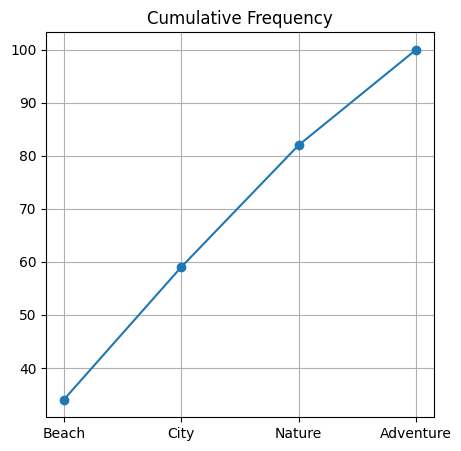

In [83]:
frequency_table["Cumulative Frequency"] = (
    frequency_table["Frequency"].cumsum()
)

print(frequency_table)

plt.figure(figsize=(5,5))
plt.plot(frequency_table['Vacation_Type'],
           frequency_table['Cumulative Frequency'],
           marker="o")
plt.title("Cumulative Frequency")
plt.grid(True)
plt.show()

# Numerical 

In [88]:
import pandas as pd

age_frequency = pd.DataFrame({
    "Age": [18, 21, 24, 27, 30, 33, 36, 39, 42, 45],
    "Frequency": [5, 8, 12, 15, 18, 14, 10, 7, 4, 2]
})

print(age_frequency)

   Age  Frequency
0   18          5
1   21          8
2   24         12
3   27         15
4   30         18
5   33         14
6   36         10
7   39          7
8   42          4
9   45          2


In [89]:
age_frequency["age_group"] = pd.cut(
    age_frequency["Age"],
    bins=[0,10,20,30,40,50,60],
    labels=["0-10","11-20","21-30","31-40","41-50","51-60"]   
)

age_frequency = age_frequency.drop(columns=["Age"])

print(age_frequency)

   Frequency age_group
0          5     11-20
1          8     21-30
2         12     21-30
3         15     21-30
4         18     21-30
5         14     31-40
6         10     31-40
7          7     31-40
8          4     41-50
9          2     41-50


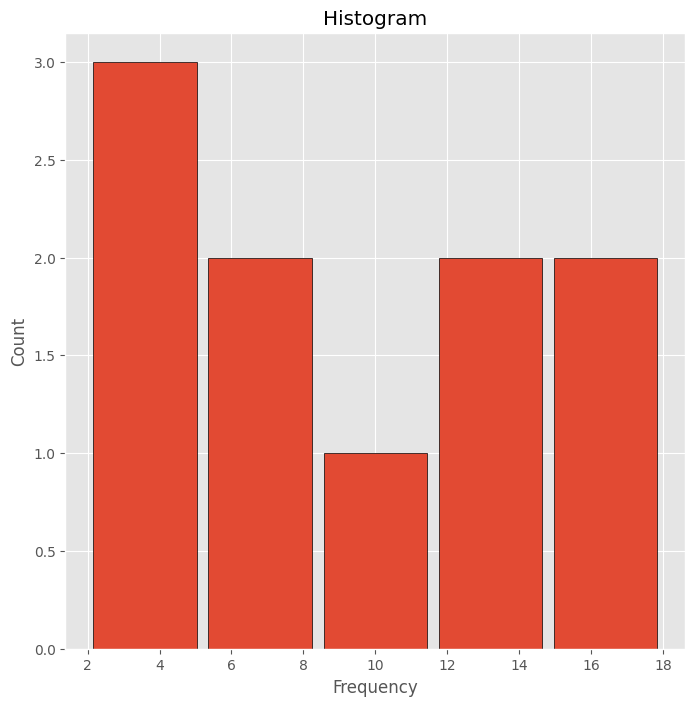

In [100]:

plt.figure(figsize=(8,8))

plt.hist(
    age_frequency["Frequency"],
    bins=5,
    edgecolor="black",
    rwidth=0.9)
plt.title("Histogram")
plt.xlabel("Frequency")
plt.ylabel("Count")
plt.show()